Разработать программу, представляющую собой форму доступа к определённым информационным ресурсам на основе пароля:
1.  В качестве информационного ресурса использовать любой файл или приложение.
2.  Доступ к ресурсу должен быть разрешен только санкционированным пользователям. Для этого в программе должны храниться имена пользователей и их пароли. При попытке доступа пользователя к ресурсу проверяется наличие его идентификатора (имени) в системе и соответствие введенного пароля паролю, который хранится в системе.
3.  В системе должна храниться следующая информация о пользователе: ID или имя пользователя, пароль, ФИО, дата рождения, место рождения (город) номер телефона.
4.  Пользователь должен иметь возможность поменять пароль (ограничения: см. вариант).

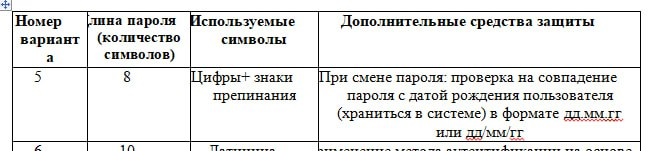

In [1]:
import numpy as np
import sqlite3
import ipywidgets as widgets
import hashlib
import re

# формируем БД учётных записей

In [2]:
import pandas as pd

data = pd.DataFrame([
{
  'user_id': 100,
 'username':'grab',
'pswd_hash': hashlib.sha256(b'Nobody').hexdigest(),
'firstname': 'Nik',
  'midname':'',
 'lastname': 'Grabovsky',
'birthdate': '1970-01-01',
  'address': 'Catsvil',
  'phoneno': '+12(34)5356',
},
{
  'user_id': 200,
 'username':'koms',
'pswd_hash': hashlib.sha256(b'dzo').hexdigest(),
'firstname': 'Mishi',
  'midname':'prof.',
 'lastname': 'Koshi',
'birthdate': '1950-01-01',
  'address': 'Pokio,Nisizabu,15',
  'phoneno': '+982(464)128790',
},
])

data.to_sql( name='Users', con=sqlite3.connect('data/users.db'), if_exists='replace', index=False )
pd.read_sql_query("SELECT * FROM Users", con=sqlite3.connect('data/users.db') )

,user_id,username,pswd_hash,firstname,midname,lastname,birthdate,address,phoneno
0,100,grab,3fad99b521aa8f8e70334722965ebbbcee4b889b12bbd9...,Nik,,Grabovsky,1970-01-01,Catsvil,+12(34)5356
1,200,koms,71c04ca18dbefd829d340edf96357f27f72e6ce7814a79...,Mishi,prof.,Koshi,1950-01-01,"Pokio,Nisizabu,15",+982(464)128790


## готовим "секретные" данные

In [3]:
# !pip install cryptography    

In [4]:
with open('data/data.txt','rt', encoding='utf-8') as f: text = f.read()

In [8]:
# !pip install cryptography

In [9]:
from cryptography.fernet import Fernet

cipher_key = Fernet.generate_key()
cipher = Fernet(cipher_key)
encrypted_text = cipher.encrypt(text.encode())
with open('data/data.bin','wb') as f:  f.write(encrypted_text)

In [10]:
# with open(data_file,'rb') as f:  encrypted_text = f.read()
# decrypted_text = cipher.decrypt(encrypted_text)
# decrypted_text.decode()

# запускаем систему

In [11]:
# список использованных форм:
# login form - вход в систему
# main menu - главное меню
# info - вывод индормации
# change paswd - смена пароля

In [12]:
class SecretGUI():
    
    # инициализация
    def __init__(self,dbname,data_file,cipher_key): 
        self._dbname = dbname  # таблица пользовтелей
        self._user = dict() # текущий активный пользователь
        self._login_form = None # ссылка на форму входа в систему
        self._main_menu_form = None # ссылка на главное меню
        self._change_pswd_form = None # ссылка на форму смены пароля
        self._info_form = widgets.HTML(value='') # ссылка на форму выдачи данных
        self._cipher = Fernet(cipher_key) # шифровальщик данных
        self._data_file = data_file # файл зашифрованных данных 
                
    def run(self): # запуск системы
        self._login_form_show() # показываем форму входа в систему
        return self

    def _show_info(self,text): # выводим данные text в форму выдачи данных
        self._info_form.close() 
        self._info_form = widgets.HTML(value=text,)
        display(self._info_form)
    
    def _show_error(self,text): # выводим данные text в форму выдачи данных
        self._info_form.close() 
        self._info_form = widgets.HTML(value=f'<font color="#f00">{text}</font>',)
        display(self._info_form)
    
    def _login_form_create(self): # создаём форму входа в систему
        t_login = widgets.Text(description='Login:', placeholder='login')
        t_pswd = widgets.Password(description='Password:', placeholder='password')
        b_login = widgets.Button(description='login') # кнопка "войти" 
        b_login.on_click(self._on_login_btn_click) # ...и её обработчик
        return widgets.VBox(children=[t_login,t_pswd,b_login])

    def _login_form_show(self): # показываем форму входа в систему
        self._login_form = self._login_form_create()
        display(self._login_form)
        return self

    def _on_login_btn_click(self,o): # обработчик кнопки "войти в систему" 
        user = self._login_form.children[0].value
        pswd = self._login_form.children[1].value
        self._login_form.close() # закрываем форму входа в систему
        self._check_login(user,pswd) # проверяем полученные данные
        return self
        
    def _check_login(self,user,pswd): # проверяем логин/пароль
        users = self._search_user(user,hashlib.sha256(pswd.encode()).hexdigest())
        if len(users)>0: # пользователь найден в БД
            self._user = users[-1]
            name = self._user['firstname']+' '+self._user['lastname']
            self._show_info(f'\nWelcome {name}') # печатаем приветствие
            self._main_menu_show() # показываем главное меню
            return self
        # пользователь НЕ найден в БД
        self._login_form_show() # возврат на форму входа в систему 
        self._show_error('\nincorrect login or password') # печатаем сообщение об ошибке
        return self
    
    def _search_user(self,login,pswd_hash):
        q = f"SELECT * FROM Users WHERE username='{login}' AND pswd_hash='{pswd_hash}';"
        users,_ = self._query_to_db(q)
        return [dict(u) for u in users]

    def _query_to_db(self,q):
        try:
            connection = sqlite3.connect(self._dbname)
            connection.row_factory = sqlite3.Row 
            result = connection.cursor().execute(q).fetchall()
            connection.commit()
        except Exception as e:
            self._show_error(f'\nerror: {e}') # печатаем  сообщение об ошибке
            return [],1
        finally:
            connection.close()
        return result,0
        
    def _main_menu_show(self):  # показываем главное меню
        self._main_menu_form = self._main_menu_form_create()
        display(self._main_menu_form)

    def _main_menu_form_create(self): # создаём главное меню
        b_show = widgets.Button(description='show secret data')
        b_show.on_click(self._on_data_show_btn_click)
        
        b_pswd = widgets.Button(description='change password')
        b_pswd.on_click(self._on_change_pswd_btn_click)
        
        b_user_info = widgets.Button(description='user info')
        b_user_info.on_click(self._on_user_info_btn_click)
        
        b_logout = widgets.Button(description='logout')
        b_logout.on_click(self._on_logout_btn_click)
        
        return widgets.HBox(children=[b_show,b_user_info,b_pswd,b_logout])

    def _on_user_info_btn_click(self,o): # обработчик кнопки "данные пользователя"
        self._main_menu_form.close() # закрываем главное меню
        t='''<table>
        <tr><td>user_id:</td><td>{user_id}</td></tr>
        <tr><td>username:</td><td>{username}</td></tr>
        <tr><td>firstname:</td><td>{firstname}</td></tr>
        <tr><td>midname:</td><td>{midname}</td></tr>
        <tr><td>lastname:</td><td>{lastname}</td></tr>
        <tr><td>birthdate:</td><td>{birthdate}</td></tr>
        <tr><td>address:</td><td>{address}</td></tr>
        <tr><td>phoneno:</td><td>{phoneno}</td></tr>
        </table>'''.format(**self._user)
        self._show_info(t) # показываем информацию
        self._main_menu_show() # показываем главное меню
        return self
        
    def _on_data_show_btn_click(self,o): # обработчик кнопки "секретные данные"
        self._main_menu_form.close() # закрываем главное меню
        
        # читаем зашифрованные данные
        with open(self._data_file,'rb') as f:  encrypted_text = f.read()
        decrypted_text = cipher.decrypt(encrypted_text) # расшифровка данных
        text = decrypted_text.decode() # конвертируем байты в строку
        
        self._show_info(text) # показываем информацию
        self._main_menu_show() # показываем главное меню
        return self
        
    def _on_logout_btn_click(self,o): # обработчик кнопки "выйти из системы"
        self._main_menu_form.close()  # закрываем главное меню
        self._info_form.close()  # закрываем форму отображения данных
        self._user = pd.DataFrame({}) # очищаем текущего пользователя
        self._login_form_show() # возврат на форму входа в систему 
        return self

    def _on_change_pswd_btn_click(self,o): # обработчик кнопки "сменить пароль"
        self._main_menu_form.close() # закрываем главное меню
        self._info_form.close() # закрываем форму отображения данных
        self._change_pswd_form_show() # показываем форму смены пароля
        return self
    
    def _change_pswd_form_create(self): # создаём форму смены пароля
        t_pswd0 = widgets.Password(description='Old Password:', placeholder='old password')
        t_pswd1 = widgets.Password(description='New Password:', placeholder='new password')
        t_pswd2 = widgets.Password(description='New Password again:', placeholder='repeat the new password')
        b_change = widgets.Button(description='change')
        b_change.on_click(self._on_enter_pswd_btn_click)
        b_cancel = widgets.Button(description='cancel')
        b_cancel.on_click(self._on_cancel_pswd_btn_click)
        return widgets.VBox(children=[t_pswd0,t_pswd1,t_pswd2,widgets.HBox(children=[b_change,b_cancel])])
    
    def _change_pswd_form_show(self):  # показываем форму смены пароля
        self._change_pswd_form = self._change_pswd_form_create()
        display(self._change_pswd_form)
        return self
    
    def _on_cancel_pswd_btn_click(self,o): # обработчик кнопки "отмена смены пароля"
        self._change_pswd_form.close() # закрываем форму смены пароля
        self._info_form.close() # закрываем форму отображения данных
        self._main_menu_show() # показываем главное меню
        return self

    def _on_enter_pswd_btn_click(self,o): # обработчик кнопки "выполнить смену пароля"
        pswd0 = self._change_pswd_form.children[0].value
        pswd1 = self._change_pswd_form.children[1].value
        pswd2 = self._change_pswd_form.children[2].value
        self._change_pswd_form.close() # закрываем форму смены пароля
        self._info_form.close()  # закрываем форму отображения данных
        self._pswd_old_verify(pswd0,pswd1,pswd2) # проверяем текущий пароль
        return self
    
    def _pswd_old_verify(self,pswd0,pswd1,pswd2,):  # проверяем текущий пароль
        pwd0_hash = hashlib.sha256(pswd0.encode()).hexdigest()
        if pwd0_hash==self._user['pswd_hash']:
             # текущий пароль корректный
            self._pswd_new_verify(pswd1,pswd2)  # проверяем новый пароль
            return self
        # текущий пароль НЕ корректный
        self._show_error('bad old password') # выводим сообщение об ошибке
        self._change_pswd_form_show() # возврат на форму смены пароля
        return self
    
    
    def _pswd_new_verify(self,pswd0,pswd1):  # проверяем новый пароль
        if pswd0!=pswd1:  # проверяем совпадение новых паролей
            # новые пароли не совпадают
            self._show_error('new passwords not match') # выводим сообщение об ошибке
            self._change_pswd_form_show()  # возврат на форму смены пароля
            return self
            
        if not self._check_pswd(pswd0): # проверяем сложность нового пароля
            # проверка НЕ пройдена
            self._show_error('bad new password') # выводим сообщение об ошибке
            self._change_pswd_form_show()  # возврат на форму смены пароля
            return self
        # проверка пройдена
        self._write_password(pswd0) # выполняем смену пароля
        
    def _check_pswd(self,pswd,): # проверяем сложность нового пароля
        dt = str(self._user['birthdate']) # день роджения пользователя
        return (
            (pswd!=dt) # пароль не совпадает с ДР
            and (len(pswd)>7)  # пароль не короче 8 символов
            and not(re.match(r'.*\d+.*',pswd) is None)  # пароль содержит цифры
            and not(re.match(r'.*[,.:;?!].*',pswd) is None)  # пароль содержит спец.символы
        )
    
    def _write_password(self,pswd): # выполняем смену пароля
        user_id = self._user['user_id'] # id пользователя 
        pswd_hash = hashlib.sha256(pswd.encode()).hexdigest() # хэш нового пароля
        # запрос к БД на смену пароля
        q = f"UPDATE Users SET pswd_hash = '{pswd_hash}' WHERE user_id={user_id};"
        _,r = self._query_to_db(q)
        if r>0: # возникла ошибка
            self._show_error(f'error password update: {e}')
            return self
       
        # пароль успешно изменён                     
        self._show_info('password updated')  # выводим сообщение об успехе
        self._main_menu_show()  # возврат в главное меню
        return self   
            

In [13]:
app = SecretGUI('data/users.db','data/data.bin',cipher_key).run() 

HTML(value='\nWelcome Nik Grabovsky')

HTML(value='У лукоморья дуб зелёный;<br/>\nЗлатая цепь на дубе том:<br/>\nИ днём и ночью кот учёный<br/>\nВсё …

HTML(value='<table>\n        <tr><td>user_id:</td><td>100</td></tr>\n        <tr><td>username:</td><td>grab</t…

HTML(value='У лукоморья дуб зелёный;<br/>\nЗлатая цепь на дубе том:<br/>\nИ днём и ночью кот учёный<br/>\nВсё …

HTML(value='<table>\n        <tr><td>user_id:</td><td>100</td></tr>\n        <tr><td>username:</td><td>grab</t…

In [ ]:
# grab: Nobody
# as23fa!ffsa